In [ ]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [ ]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## Consistency Model — Sea Ice Concentration (SIC)

In [15]:
!nvidia-smi

Wed Jun 24 19:29:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   55C    P0            134W /  300W |   14009MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

env: CUDA_VISIBLE_DEVICES=3


In [17]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')     # -> consistency/  (consistency_models, spectral_utils)
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.utils
import consistency_models.consistency_models_CM
importlib.reload(consistency_models.utils)
importlib.reload(consistency_models.consistency_models_CM)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_, pseudo_huber_loss

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed -- CRPS disabled.")

## ⚠️ ACTION REQUIRED — automatically generated notebook

This notebook (`UNet` / `SIC`) was assembled by `sbatch_submission/generate_missing_notebooks.py`, combining the data loading of xp `SIC` with the method code of the GP reference notebook. Points to validate before a production run:

- **LOG_DIR** automatically set to `logs_direct_unet_SIC` — check it doesn't collide with an existing run.
- **sigma_max / SIGMA_NOISE**: value carried over as-is from the GP source notebook — needs to be re-tuned to this variable's physical scale (cf. SIC ≈ 1.0, SSH_GF ≈ 10, GP to verify) before any production run.
- **cond_channels**: `UNetConfig(channels=C)` was automatically rewritten to `UNetConfig(channels=C, cond_channels=2*C)` (factor inferred from the existing SIC/CM notebook). Verify this factor is correct for the config class used by **UNet** (may differ from CM's) and that the forward pass actually concatenates the right conditioning fields.
- **Masked loss (NaN)**: this xp has NaN gaps in the target. The matching FM notebook (`Notebook_flowmatching_model_FM_sic.ipynb`, class `LitFlowMatchingSIC.training_step`) already implements masking via `masked_average` — **this generated notebook did NOT reproduce it automatically** for this method's Lightning class. Must be done before any real training run, otherwise the model will train on NaN noise.

## DataModule -- SIC (ASIP / OSISAF)

C=9, H=240, W=240
Train: 300, Val: 50, Test: 43
asip: (9, 240, 240)  input: (9, 240, 240)  osisaf: (9, 240, 240)
asip range: [0.000, 1.000]
asip std: 0.4139
NaN fraction in asip: 22.2%


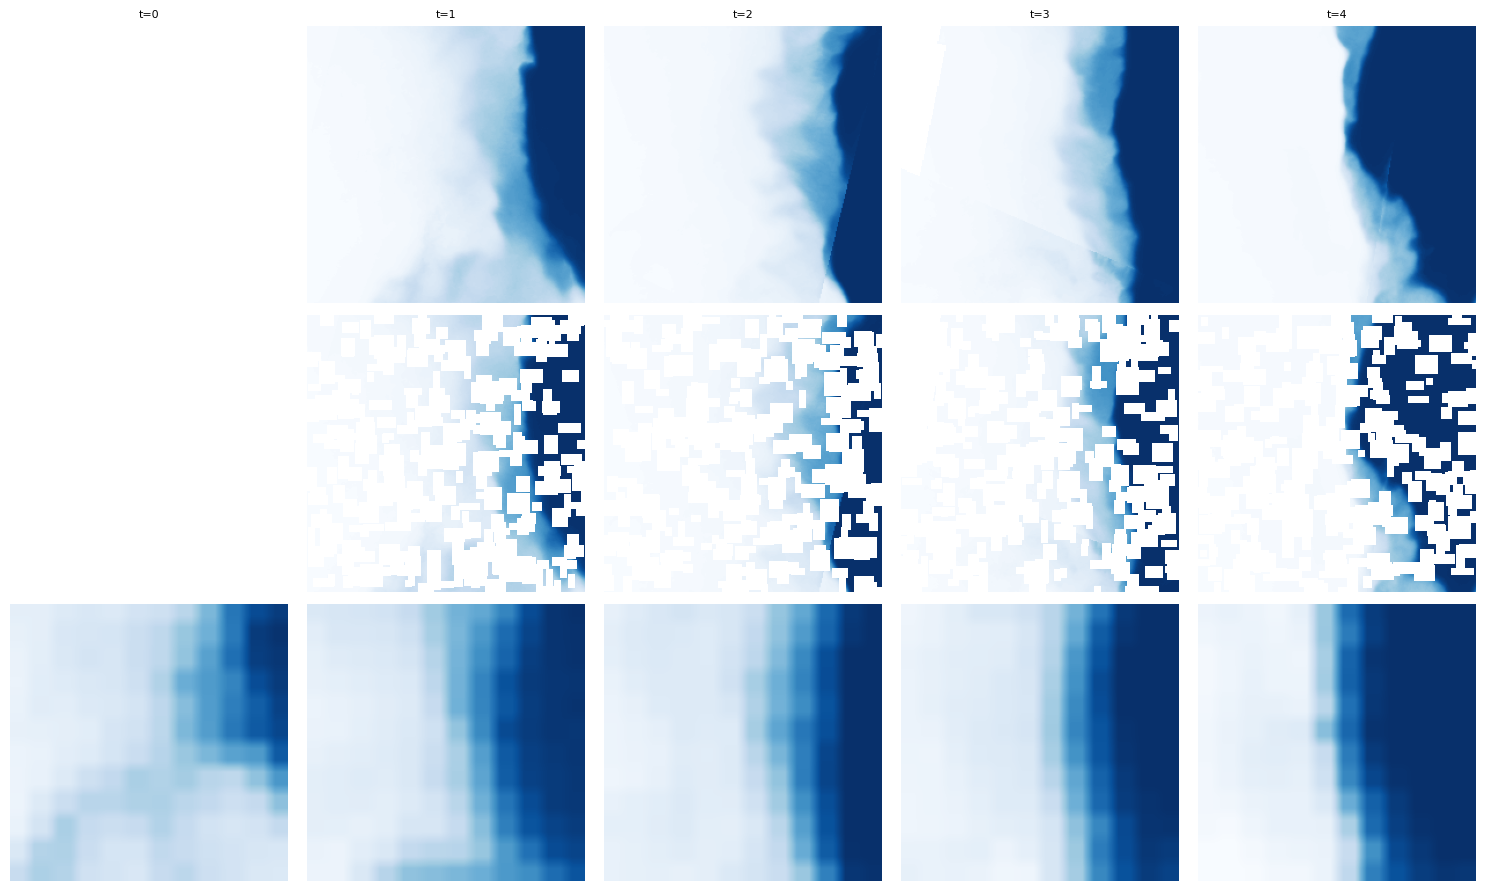

In [ ]:
sys.path.insert(0, '../../..')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import functools as ft
from contrib.ASIP_OSISAF.data_simple import BaseDataModule, TrainingItem_4da

T_CROP = 9

class CroppedDataModule(BaseDataModule):
    def __init__(self, *args, t_crop=9, **kwargs):
        super().__init__(*args, **kwargs)
        self.t_crop = t_crop

    def build_batch(self):
        # ASIP/input/osisaf are already in [0, 1] in the NetCDF file — no rescaling needed
        return ft.partial(ft.reduce, lambda i, f: f(i), [
            TrainingItem_4da._make,
        ])

    def setup(self, stage='test'):
        super().setup(stage)
        for ds in [self.train_ds, self.val_ds, self.test_ds]:
            ds.db = ds.db.isel(time=slice(-self.t_crop, None))

datamodule = CroppedDataModule(
    asip_paths="../../../data/asip_database_daw15_sparse.nc",
    split_train=slice(0, 300),
    split_val=slice(300, 350),
    split_test=slice(350, 393),
    da=True,
    norm_stats=[0, 1],
    norm_stats_covs=[
        {'t2m': 270.08, 'istl1': 267.68, 'siconc': 0, 'sst': 276.97, 'skt': 270.50},
        {'t2m': 14.67,  'istl1': 7.80,  'siconc': 1, 'sst': 6.82,   'skt': 15.21},
    ],
    t_crop=T_CROP,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.asip.shape[0]
H, W = sample.asip.shape[1], sample.asip.shape[2]
print(f"C={C}, H={H}, W={W}")
print(f"Train: {len(datamodule.train_ds)}, Val: {len(datamodule.val_ds)}, Test: {len(datamodule.test_ds)}")
print(f"asip: {sample.asip.shape}  input: {sample.input.shape}  osisaf: {sample.osisaf.shape}")
print(f"asip range: [{np.nanmin(sample.asip):.3f}, {np.nanmax(sample.asip):.3f}]")
print(f"asip std: {np.nanstd(sample.asip):.4f}")
print(f"NaN fraction in asip: {np.isnan(sample.asip).mean()*100:.1f}%")

fig, axes = plt.subplots(3, min(C, 5), figsize=(3 * min(C, 5), 9))
for t_idx in range(min(C, 5)):
    axes[0, t_idx].imshow(sample.asip[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[0, t_idx].set_title(f't={t_idx}', fontsize=8); axes[0, t_idx].axis('off')
    axes[1, t_idx].imshow(sample.input[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[1, t_idx].axis('off')
    axes[2, t_idx].imshow(sample.osisaf[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[2, t_idx].axis('off')
axes[0, 0].set_ylabel('ASIP (target)', fontsize=10)
axes[1, 0].set_ylabel('Input (gappy)', fontsize=10)
axes[2, 0].set_ylabel('OSISAF (cond.)', fontsize=10)
plt.tight_layout()
plt.show()

### UNet Building Blocks


In [29]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100×100 → 104×104, must be a multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)  # left, right, top, bottom
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### Direct UNet

The UNet takes as input the concatenation `(y_filled, mask_obs)` → `2×C` input channels.
A reflection padding to the nearest multiple of 8 is applied at input and removed at output.
There is no noise-level conditioning (a zero dummy embedding is used to preserve the UNetBlock interface).


In [30]:
@dataclass
class DirectUNetConfig:
    channels: int = 5                                        # = window_size
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class DirectUNet(nn.Module):
    """
    Direct UNet for field reconstruction from sparse observations.

    Input:  cat(y_filled, mask_obs)  →  2*C channels
    Output: x_hat                    →  C channels

    y_filled : (B, C, H, W)  observations with NaN → 0
    mask_obs : (B, C, H, W)  binary float (1=observed, 0=missing)
    """
    def __init__(self, config: DirectUNetConfig) -> None:
        super().__init__()
        self.config = config
        C = config.channels
        D = config.top_blocks_channels[0]
        COND = 1   # dummy conditioning dimension

        # Project (y_filled, mask) jointly: 2C → D
        self.input_projection = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        # Dummy noise-level embedding (always zeros) — keeps UNetBlock interface
        self.dummy_emb = nn.Linear(COND, COND)

        all_channels = config.top_blocks_channels + config.mid_blocks_channels
        n_blocks     = (config.top_blocks_n_blocks_per_resolution
                        + config.mid_blocks_n_blocks_per_resolution)
        has_res      = (config.top_blocks_has_resampling
                        + config.mid_blocks_has_resampling)
        dropouts     = (config.top_blocks_dropout + config.mid_blocks_dropout)

        enc_channels = [D] + list(all_channels)
        self.encoder_blocks = nn.ModuleList()
        self.downsamplers    = nn.ModuleList()
        for i in range(len(all_channels)):
            blocks = nn.ModuleList([
                UNetBlock(enc_channels[i] if j == 0 else all_channels[i],
                          all_channels[i], COND, dropouts[i])
                for j in range(n_blocks[i])
            ])
            self.encoder_blocks.append(blocks)
            self.downsamplers.append(Downsample(all_channels[i]) if has_res[i] else nn.Identity())

        self.attention = SelfAttention(all_channels[-1], all_channels[-1], config.n_heads)

        # Decoder. The forward pass upsamples the *incoming* feature map (the previous
        # stage's output) before concatenating the skip, so every module at stage i must
        # be sized by the incoming channel count `prev_channels[i]`, not `dec_channels[i]`.
        dec_channels  = list(reversed(all_channels))                 # [512, 256, 128, 64]
        prev_channels = [all_channels[-1]] + dec_channels[:-1]       # [512, 512, 256, 128]
        self.decoder_blocks = nn.ModuleList()
        self.upsamplers      = nn.ModuleList()
        for i in range(len(dec_channels)):
            skip_ch = dec_channels[i]
            in_ch   = prev_channels[i] + skip_ch
            blocks  = nn.ModuleList([
                UNetBlock(in_ch if j == 0 else dec_channels[i],
                          dec_channels[i], COND, dropouts[-(i+1)])
                for j in range(n_blocks[-(i+1)])
            ])
            self.decoder_blocks.append(blocks)
            self.upsamplers.append(
                Upsample(prev_channels[i]) if has_res[-(i+1)] else nn.Identity()
            )

        self.output_projection = nn.Sequential(
            GroupNorm(dec_channels[-1]),
            nn.SiLU(),
            nn.Conv2d(dec_channels[-1], C, kernel_size=3, padding="same"),
        )

    @staticmethod
    def _pad(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int,int,int,int]]:
        H, W = x.shape[-2], x.shape[-1]
        pad_h = (multiple - H % multiple) % multiple
        pad_w = (multiple - W % multiple) % multiple
        padding = (0, pad_w, 0, pad_h)
        return F.pad(x, padding, mode="reflect"), padding

    @staticmethod
    def _unpad(x: Tensor, padding: Tuple[int,int,int,int]) -> Tensor:
        _, pad_w, _, pad_h = padding
        if pad_h > 0: x = x[..., :-pad_h, :]
        if pad_w > 0: x = x[..., :-pad_w]
        return x

    def forward(self, y_filled: Tensor, mask_obs: Tensor) -> Tensor:
        x = torch.cat([y_filled, mask_obs], dim=1)   # (B, 2C, H, W)
        x, padding = self._pad(x)
        x = self.input_projection(x)                 # (B, D, H', W')

        # 4D dummy conditioning (B, COND, 1, 1) — time_level_projection is a Conv2d
        cond = torch.zeros(x.shape[0], 1, 1, 1, device=x.device, dtype=x.dtype)

        skips = []
        for blocks, down in zip(self.encoder_blocks, self.downsamplers):
            for blk in blocks:
                x = blk(x, cond)
            skips.append(x)
            x = down(x)

        x = self.attention(x)

        for blocks, up, skip in zip(self.decoder_blocks, self.upsamplers,
                                     reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            for blk in blocks:
                x = blk(x, cond)

        x = self.output_projection(x)
        return self._unpad(x, padding)

    def save_pretrained(self, path: str) -> None:
        os.makedirs(path, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(path, "model.pt"))
        with open(os.path.join(path, "config.json"), "w") as f:
            json.dump(asdict(self.config), f)

    @classmethod
    def from_pretrained(cls, path: str) -> "DirectUNet":
        with open(os.path.join(path, "config.json")) as f:
            cfg = DirectUNetConfig(**json.load(f))
        model = cls(cfg)
        model.load_state_dict(torch.load(os.path.join(path, "model.pt"),
                                          map_location="cpu"))
        return model


### LightningModule — LitDirectUNet


In [31]:
@dataclass
class LitDirectUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)


class LitDirectUNet(LightningModule):
    """
    Lightning wrapper for direct UNet reconstruction.

    training_step:
        1. Build y_filled and mask from batch.input (NaN → 0)
        2. Predict x_hat = model(y_filled, mask)
        3. Loss = MSE(x_hat, batch.tgt) over all pixels
    """

    def __init__(self, model: nn.Module,
                 config: LitDirectUNetConfig = LitDirectUNetConfig()) -> None:
        super().__init__()
        self.model  = model
        self.config = config

    def _prepare_inputs(self, y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    def training_step(self, batch, batch_idx: int):
        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx: int):
        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)
        rmse  = loss.sqrt()
        self.log_dict({"val_loss": loss, "val_rmse": rmse}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(),
                                lr=self.config.lr, betas=self.config.betas)


## 🚀 Training


In [37]:
import shutil

def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"Valid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("No valid checkpoint found. Starting from scratch.")
    return None

LOG_DIR     = "logs_direct_unet_SIC"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above

if RESET_TRAINING:
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    print("RESET_TRAINING=True -- starting from scratch")

resume_ckpt = None if RESET_TRAINING else find_best_valid_checkpoint(CKPT_DIR)

seed_everything(42)

unet_cfg = DirectUNetConfig(channels=C, cond_channels=2*C)
model    = DirectUNet(unet_cfg)
lit_model = LitDirectUNet(model)

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_rmse",
            mode="min",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_rmse:.4f}",
        ),
    ],
)

trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_model, datamodule, ckpt_path=resume_ckpt)

lit_model.model.save_pretrained(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")


Global seed set to 42


Valid checkpoint: logs_direct_unet_GP/v1/checkpoints/last.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_direct_unet_GP/v1/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
Restoring states from the checkpoint path at logs_direct_unet_GP/v1/checkpoints/last.ckpt


[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name  | Type       | Params
-------------------------------------
0 | model | DirectUNet | 58.8 M
-------------------------------------
58.8 M    Trainable params
0         Non-trainable params
58.8 M    Total params
235.254   Total estimated model params size (MB)
Restored all states from the checkpoint at logs_direct_unet_GP/v1/checkpoints/last.ckpt


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


Model saved to: logs_direct_unet_GP/v1/best_model


## 🎲 Inference & Evaluation  ### Checkpoint Loading


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_direct_unet_GP", "best_model")

model = DirectUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"DirectUNet loaded from {MODEL_PATH}")
print(f"  Device : {next(model.parameters()).device}")
print(f"  Params : {sum(p.numel() for p in model.parameters()):,}")


DirectUNet loaded from logs_direct_unet_GP/v1/best_model
  Device : cuda:0
  Params : 58,813,511


### Test Batch & Inference


In [39]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

y      = batch.input.to(device=device, dtype=dtype)   # (B, C, H, W)  sparse obs (NaN=missing)
x_true = batch.tgt  .to(device=device, dtype=dtype)   # (B, C, H, W)  ground truth

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    x_hat = model(y_filled, mask)                     # (B, C, H, W)  reconstruction

rmse_val = (x_hat - x_true).pow(2).mean().sqrt().item()
print(f"RMSE (test batch, normalised): {rmse_val:.4f}")

m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
_b = 0  # batch index


Global seed set to 42


RMSE (test batch, normalised): 0.9969


## 📊 Metrics — DirectUNet vs OI

Evaluation at the **centre of the assimilation window** (`t=T_EVAL`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of prediction |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |


t=2 | sigma(GT)=0.2475

## Metrics @ t=2 -- 1 pixel = 1 km



,Score ↑,RMSE ↓,σ_GT,σ_pred,λx [px]
Method,,,,,
DirectUNet,0.026,0.2411,0.2475,0.2003,31.2
OI baseline,0.108,0.2208,0.2475,0.1484,44.6


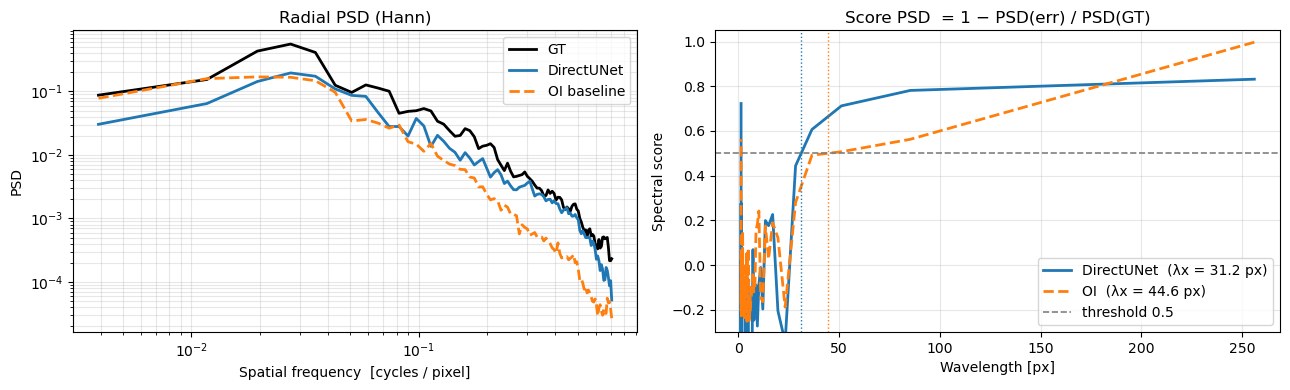

In [40]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

T_EVAL = datamodule.window_size // 2   # centre of assimilation window
DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

# Fields at time T_EVAL — denormalise to physical units
gt_n    = x_true[_b, T_EVAL].float().cpu().numpy()   # (H, W) normalized
gt_p    = gt_n   * s_norm + m_norm

pred_n  = x_hat[_b, T_EVAL].float().cpu().numpy()    # (H, W) normalized
pred_p  = pred_n * s_norm + m_norm

oi_p    = datamodule.oi[start_t + T_EVAL].astype(np.float32)   # (H, W) physical

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f}')

def _metrics_row(pred_p, gt_p, label, dx=DX_PX):
    sigma      = float(np.nanstd(gt_p))
    rmse_v     = float(np.sqrt(np.nanmean((pred_p - gt_p) ** 2)))
    score      = 1.0 - rmse_v / sigma
    sigma_pred = float(np.nanstd(pred_p))
    wl, _, _, spec = psd_spectral_score(pred_p, gt_p, dx=dx)
    lambda_x   = resolved_scale(wl, spec, threshold=0.5)
    return {
        'Method'   : label,
        'Score ↑'  : f'{score:.3f}',
        'RMSE ↓'   : f'{rmse_v:.4f}',
        'σ_GT'     : f'{sigma:.4f}',
        'σ_pred'   : f'{sigma_pred:.4f}',
        'λx [px]'  : f'{lambda_x:.1f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_du, wl_du, spec_du = _metrics_row(pred_p, gt_p, 'DirectUNet')
row_oi, wl_oi, spec_oi = _metrics_row(oi_p,   gt_p, 'OI baseline')

df_metrics = pd.DataFrame([row_du, row_oi]).set_index('Method')
df_metrics.columns = ['Score ↑','RMSE ↓','σ_GT','σ_pred','λx [px]']
print(f'\n## Metrics @ t={T_EVAL} -- 1 pixel = {DX_PX:.0f} km\n')
display(df_metrics)

# ── Signal PSDs (radial, Hann-windowed) ───────────────────────────────────────
wl_gt,  psd_gt_sig  = radial_psd_2d(gt_p,   dx=DX_PX)
wl_du2, psd_du_sig  = radial_psd_2d(pred_p, dx=DX_PX)
wl_oi2, psd_oi_sig  = radial_psd_2d(oi_p,   dx=DX_PX)

lambda_x_du = resolved_scale(wl_du, spec_du)
lambda_x_oi = resolved_scale(wl_oi, spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,  psd_gt_sig,  'black', '-',  'GT'),
    (wl_du2, psd_du_sig,  'C0',   '-',  'DirectUNet'),
    (wl_oi2, psd_oi_sig,  'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title('Radial PSD (Hann)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_du = f'DirectUNet  (λx = {lambda_x_du:.1f} px)' if not np.isnan(lambda_x_du) else 'DirectUNet'
lbl_oi = f'OI  (λx = {lambda_x_oi:.1f} px)'          if not np.isnan(lambda_x_oi) else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_du, spec_du, 'C0', '-',  lbl_du),
    (wl_oi, spec_oi, 'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_du):
    ax.axvline(lambda_x_du, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi, color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Publication Figures


  Saved: figures/DirectUNet_GP/DirectUNet_GP_obs.png


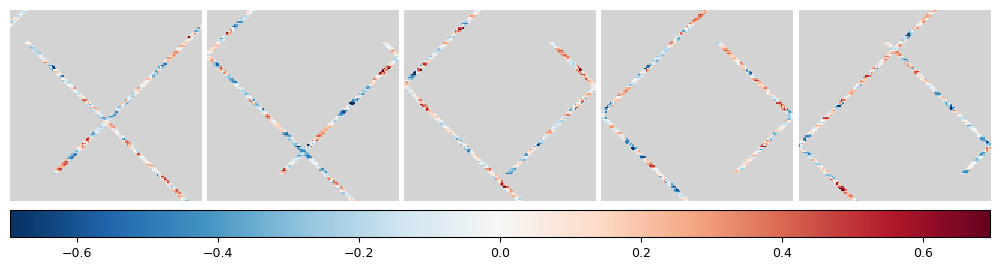

  Saved: figures/DirectUNet_GP/DirectUNet_GP_gt.png


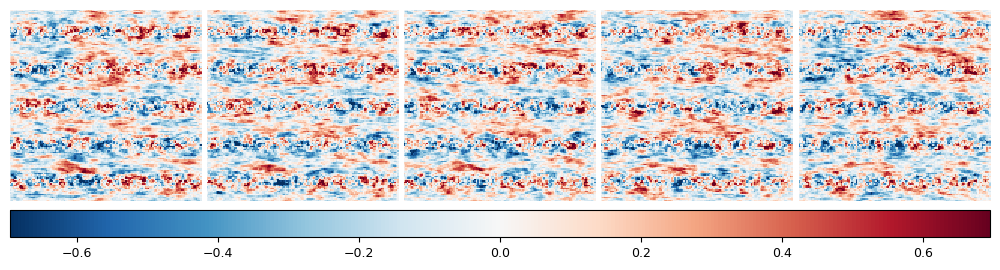

  Saved: figures/DirectUNet_GP/DirectUNet_GP_oi.png


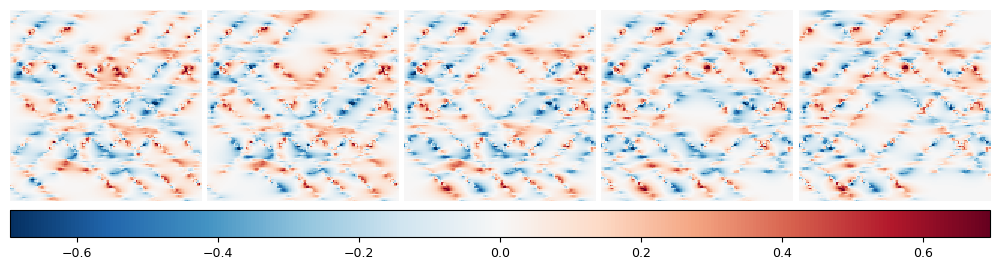

  Saved: figures/DirectUNet_GP/DirectUNet_GP_pred.png


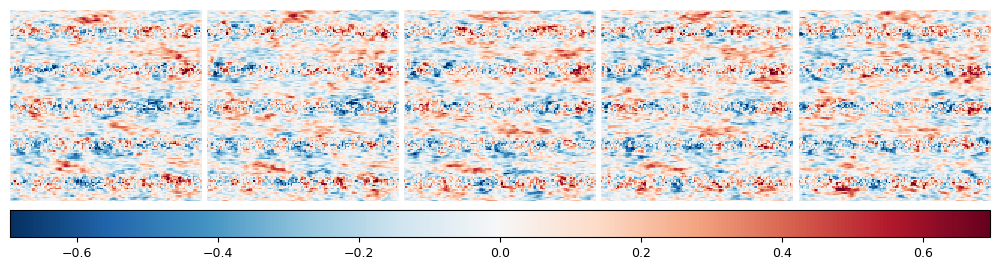

In [41]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'DirectUNet_GP'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size
ws = C

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm   # (C,H,W)
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + ws].astype(np.float32)
pred_phys = x_hat[_b].float().cpu().numpy()       * s_norm + m_norm   # (C,H,W)

# Land mask (batch.land_mask == 1 -> land), same grid as the fields above.
is_land = batch.land_mask[_b].float().cpu().numpy() >= 0.5
print(f'Land fraction (masked out): {is_land.mean()*100:.1f}%')
for _arr in (obs_phys, gt_phys, oi_phys, pred_phys):
    _arr[is_land] = np.nan

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',  vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',   vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',   vmin_f, vmax_f, cmap_f),
    (pred_phys, f'{FIG_TAG}_pred', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
